# Notebook 03 — Attention Visualisation.

In [1]:
from pathlib import Path
import os, sys

repo = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if not (repo / "src").exists():
    repo = Path.cwd().parent.parent
sys.path.insert(0, str(repo))

import numpy as np
import matplotlib.pyplot as plt
import torch

from src.data_pipeline.ingestion import generate_synthetic_transactions
from src.data_pipeline.graph_builder import build_pyg_data
from src.models.gatv2 import GATv2Net
from src.models.loss import AdaptiveFocalLoss


## Load graph and run a forward pass capturing attention weights

In [2]:
df = generate_synthetic_transactions(n_accounts=60, n_transactions=200, seed=3)
data, _ = build_pyg_data(df)
model = GATv2Net(in_channels=data.num_node_features, hidden_channels=33, heads=3,
                 edge_dim=data.edge_attr.shape[-1], num_classes=2)


[2026-08-27 20:56:25,343] [INFO] [src.data_pipeline.ingestion] Generated 200 synthetic transactions over 60 accounts (2.00% flagged)


[2026-08-27 20:56:25,366] [INFO] [src.data_pipeline.graph_builder] Built graph: 60 nodes, 200 edges, 9 node features, 2 edge features


## Visualisation of node embeddings (t-SNE-like PCA)

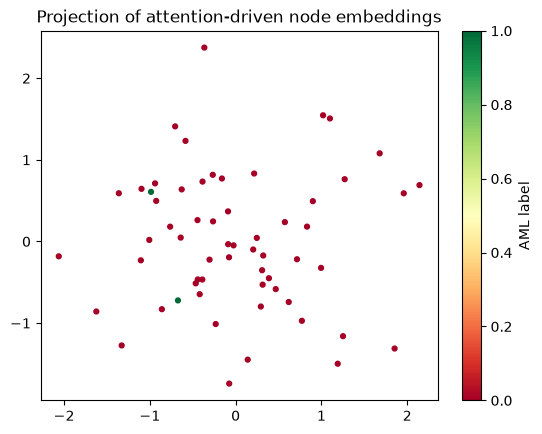

In [3]:
from sklearn.decomposition import PCA

with torch.no_grad():
    logits = model(data.x, data.edge_index, edge_attr=data.edge_attr)
emb = logits.detach().numpy()
if emb.shape[0] > 2:
    proj = PCA(n_components=2).fit_transform(emb)
    plt.scatter(proj[:, 0], proj[:, 1], c=data.y.numpy(), cmap="RdYlGn", s=12)
    plt.colorbar(label="AML label")
    plt.title("Projection of attention-driven node embeddings")
    plt.show()


## Attention head histogram

attention samples: [[0.363  0.1235 0.0921]
 [0.104  0.0437 0.081 ]
 [0.0902 0.1872 0.222 ]
 [0.2155 0.2178 0.1619]
 [0.2115 0.3198 0.2408]
 [0.5771 0.669  0.3873]
 [0.1261 0.2141 0.479 ]
 [0.2582 0.3194 0.2949]
 [0.2048 0.1703 0.3439]
 [0.0726 0.1722 0.244 ]]


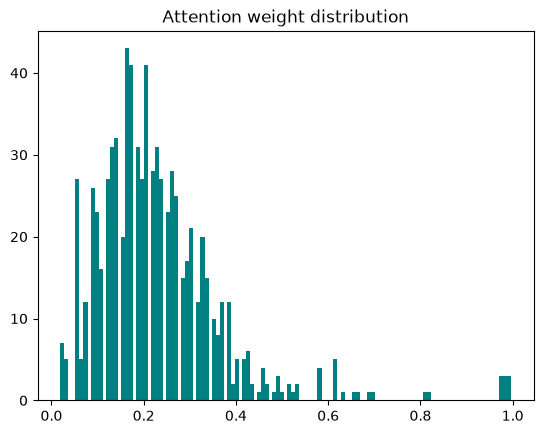

In [4]:
from torch_geometric.nn import GATv2Conv
import torch

# Use the final layer edge_index for a k-hop subgraph of attention weights.
torch.manual_seed(0)
conv = GATv2Conv(data.num_node_features, 16, heads=3, concat=False,
                 edge_dim=data.edge_attr.shape[-1])
out, (ei, alpha) = conv(data.x, data.edge_index, data.edge_attr, return_attention_weights=True)
print("attention samples:", alpha[:10].detach().numpy().round(4))
plt.hist(alpha.detach().numpy(), bins=30, color="teal")
plt.title("Attention weight distribution")
plt.show()


## Loss convergence curve over a short run

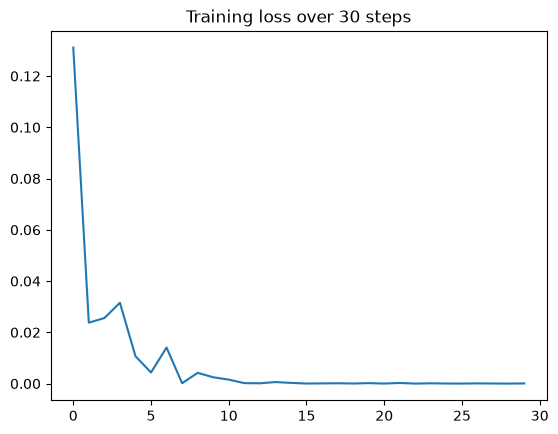

roc_auc=1.000


In [5]:
import torch

model.train()
opt = torch.optim.Adam(model.parameters(), lr=0.01)
lab = AdaptiveFocalLoss(init_alpha=0.25, init_gamma=2.0)
history = []
for _ in range(30):
    opt.zero_grad()
    out = model(data.x, data.edge_index, edge_attr=data.edge_attr)
    l = lab(out, data.y)
    l.backward()
    opt.step()
    history.append(float(l))
from sklearn.metrics import roc_auc_score

plt.plot(history)
plt.title("Training loss over 30 steps")
plt.show()
probs = torch.softmax(out, dim=-1)[:, 1].detach().numpy()
print(f"roc_auc={roc_auc_score(data.y.numpy(), probs):.3f}")
